# Imports

In [120]:
import matplotlib.pyplot as plt
import numpy as np
from pmc import PMC

# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [121]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
      -1,
      -1
])

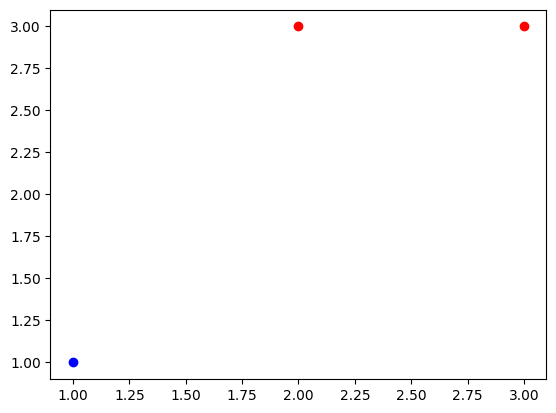

<Figure size 640x480 with 0 Axes>

In [122]:
plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

Loss finale : 0.003844


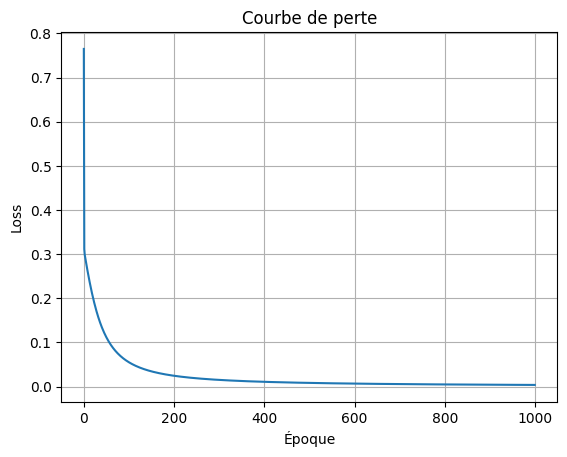

In [123]:
model = PMC([2, 1], learning_rate=0.1)

losses = []
for epoch in range(1000):
    loss = model.train(X, Y)
    losses.append(loss)

print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses)
plt.title("Courbe de perte")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.grid(True)
plt.show()

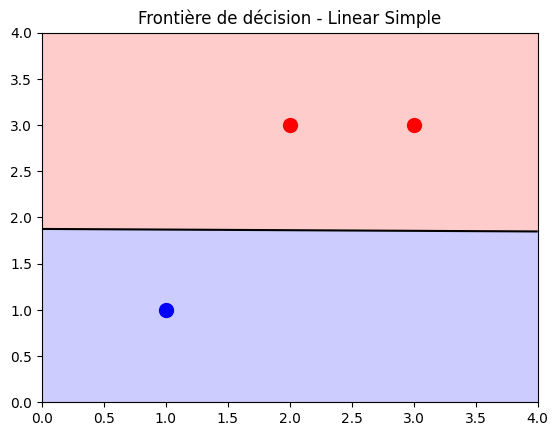

In [124]:
xx, yy = np.meshgrid(np.linspace(0, 4, 300), np.linspace(0, 4, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0, 0], X[0, 1], color='blue', s=100, zorder=5)
plt.scatter(X[1:3, 0], X[1:3, 1], color='red', s=100, zorder=5)
plt.title("Frontière de décision - Linear Simple")
plt.show()

In [125]:
print("Point     | Sortie | Attendu")
print("-" * 35)
for x, exp in zip(X, [1, -1, -1]):
    
    out = model.forward(x)[0]
    print(f"  {x}  →  {out:+.4f}  (attendu {exp:+d})")


Point     | Sortie | Attendu
-----------------------------------
  [1 1]  →  +0.8718  (attendu +1)
  [2 3]  →  -0.9419  (attendu -1)
  [3 3]  →  -0.9431  (attendu -1)


### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [126]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

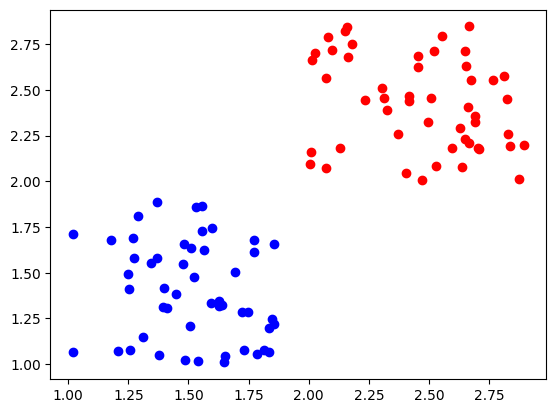

<Figure size 640x480 with 0 Axes>

In [127]:
plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()

Loss finale : 0.040943


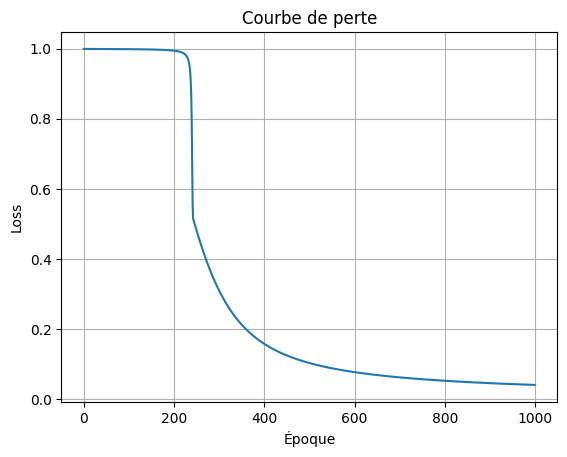

In [128]:
model = PMC([2, 1], learning_rate=0.1)

losses = []
for epoch in range(1000):
    loss = model.train(X, Y)
    losses.append(loss)

print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses)
plt.title("Courbe de perte")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.grid(True)
plt.show()

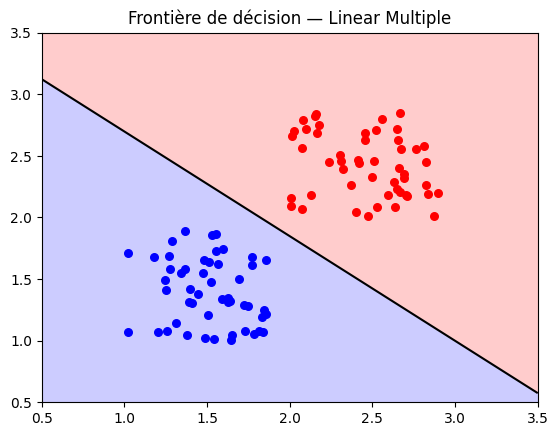

In [129]:
xx, yy = np.meshgrid(np.linspace(0.5, 3.5, 300), np.linspace(0.5, 3.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0:50, 0],   X[0:50, 1],   color='blue', s=30, zorder=5)
plt.scatter(X[50:100, 0], X[50:100, 1], color='red',  s=30, zorder=5)
plt.title("Frontière de décision — Linear Multiple")
plt.show()

In [130]:
labels = np.concatenate([np.zeros(50), np.ones(50)]) 
acc = model.accuracy(X, labels)
print(f"Accuracy : {acc * 100:.1f}%")

cm = model.confusion_matrix(X, labels)
print("Matrice de confusion :")
print(cm)

Accuracy : 100.0%
Matrice de confusion :
[[50  0]
 [ 0 50]]


### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [131]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

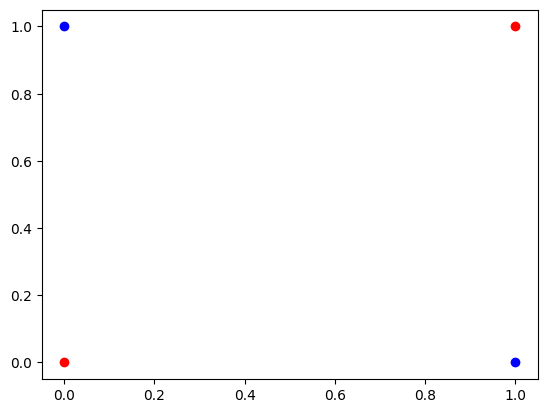

<Figure size 640x480 with 0 Axes>

In [132]:
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

Loss finale : 0.004022


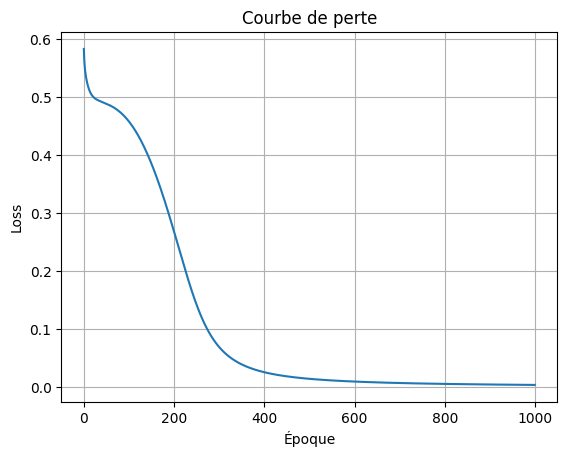

In [133]:
model = PMC([2, 2, 1], learning_rate=0.1)

losses = []
for epoch in range(1000):
    loss = model.train(X, Y)
    losses.append(loss)

print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses)
plt.title("Courbe de perte")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.grid(True)
plt.show()

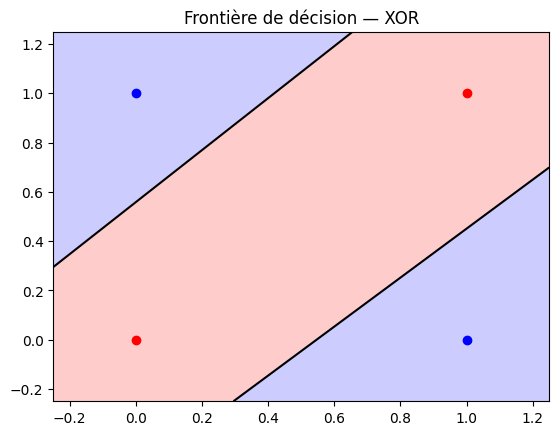

In [134]:
xx, yy = np.meshgrid(np.linspace(-0.25, 1.25, 300), np.linspace(-0.25, 1.25, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.title("Frontière de décision — XOR")
plt.show()


























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [135]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

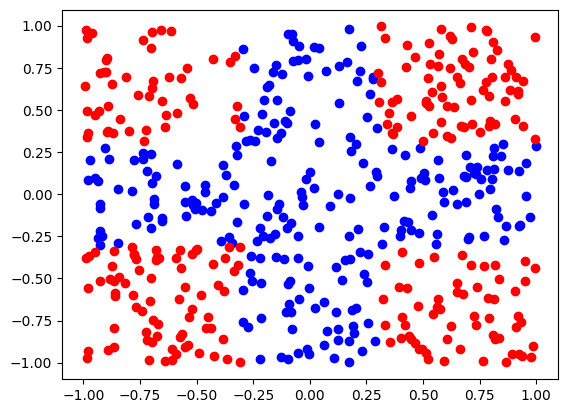

<Figure size 640x480 with 0 Axes>

In [136]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

Loss finale : 0.015395


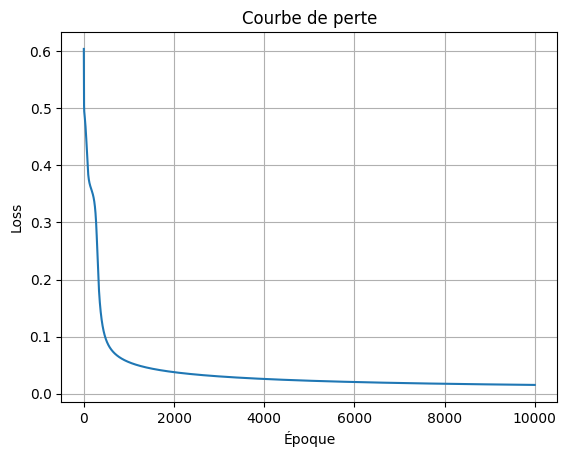

In [137]:
model = PMC([2, 4, 1], learning_rate=0.5)

losses = []
for epoch in range(10000):
    loss = model.train(X, Y)
    losses.append(loss)

print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses)
plt.title("Courbe de perte")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.grid(True)
plt.show()

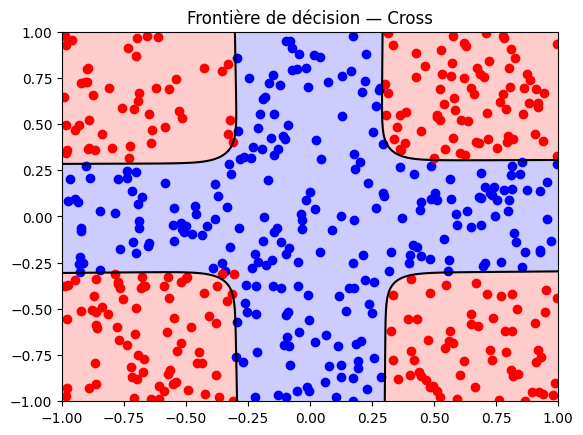

In [138]:
xx, yy = np.meshgrid(np.linspace(-1, 1, 300), np.linspace(-1, 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.title("Frontière de décision — Cross")
plt.show()


### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [139]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

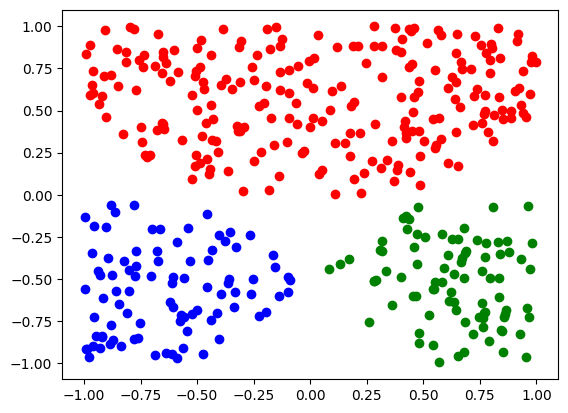

<Figure size 640x480 with 0 Axes>

In [140]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

Loss finale : 0.025035


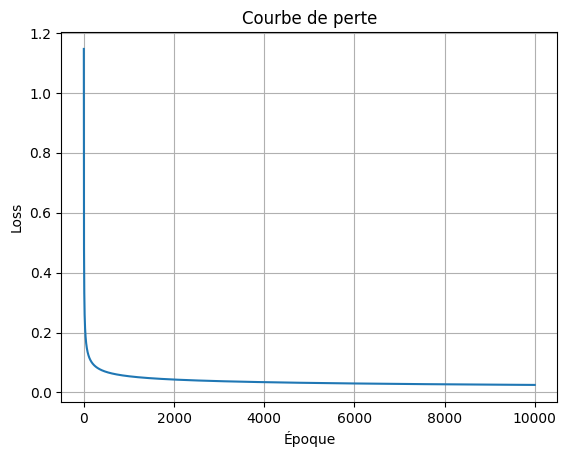

In [141]:
model = PMC([2, 3], learning_rate=0.5)

losses = []
for epoch in range(10000):
    loss = model.train(X, Y)
    losses.append(loss)

print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses)
plt.title("Courbe de perte")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.grid(True)
plt.show()

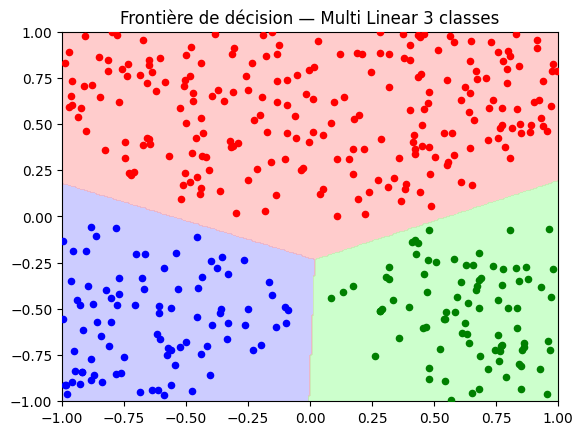

In [142]:
xx, yy = np.meshgrid(np.linspace(-1, 1, 300), np.linspace(-1, 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

preds = np.array([model.forward(pt) for pt in grid])
classes = np.argmax(preds, axis=1).reshape(xx.shape)

plt.contourf(xx, yy, classes, levels=[-0.5, 0.5, 1.5, 2.5],
             colors=['#aaaaff', '#ffaaaa', '#aaffaa'], alpha=0.6)

# Points réels
blue  = X[Y[:, 0] == 1]
red   = X[Y[:, 1] == 1]
green = X[Y[:, 2] == 1]

plt.scatter(blue[:,0],  blue[:,1],  color='blue',  s=20, zorder=5)
plt.scatter(red[:,0],   red[:,1],   color='red',   s=20, zorder=5)
plt.scatter(green[:,0], green[:,1], color='green', s=20, zorder=5)

plt.title("Frontière de décision — Multi Linear 3 classes")
plt.show()

### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [143]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

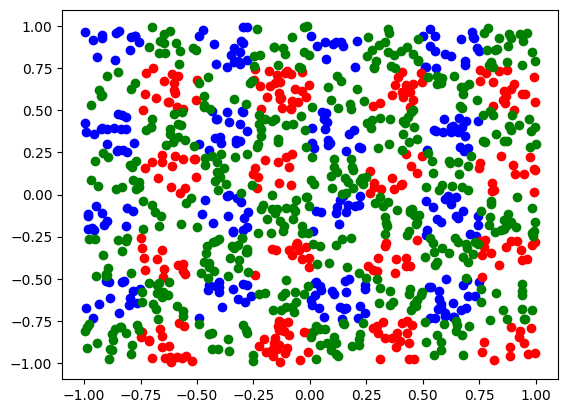

<Figure size 640x480 with 0 Axes>

In [144]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

Loss finale : 0.002017


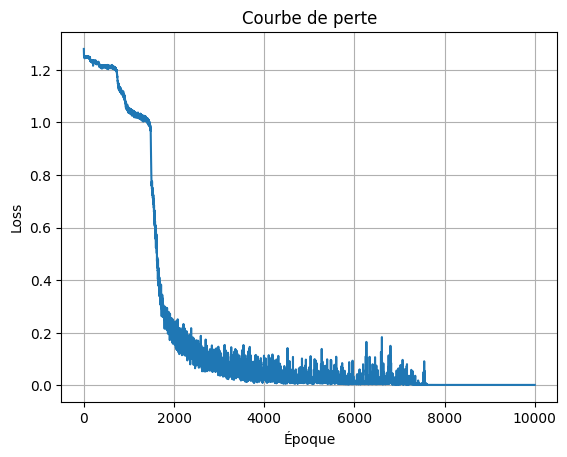

In [145]:
model = PMC([2, 32, 32, 3], learning_rate=0.01)

losses = []
for epoch in range(10000):
    idx = np.random.permutation(len(X))
    epoch_loss = 0.0
    for i in idx:
        epoch_loss += model.train(X[i:i+1], Y[i:i+1])
    losses.append(epoch_loss / len(X))

print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses)
plt.title("Courbe de perte")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.grid(True)
plt.show()

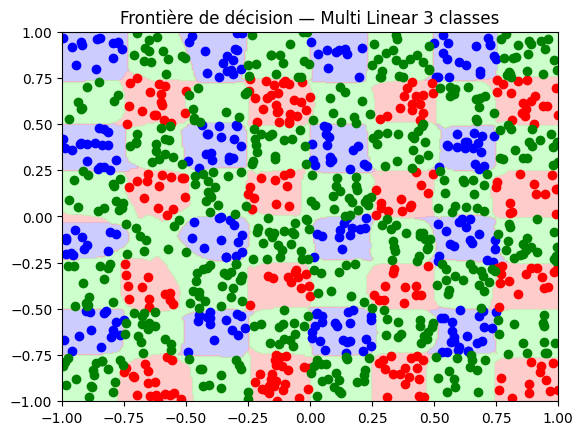

In [146]:
xx, yy = np.meshgrid(np.linspace(-1, 1, 300), np.linspace(-1, 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

preds = np.array([model.forward(pt) for pt in grid])
classes = np.argmax(preds, axis=1).reshape(xx.shape)

plt.contourf(xx, yy, classes, levels=[-0.5, 0.5, 1.5, 2.5],
             colors=['#aaaaff', '#ffaaaa', '#aaffaa'], alpha=0.6)

# Points réels
blue  = X[Y[:, 0] == 1]
red   = X[Y[:, 1] == 1]
green = X[Y[:, 2] == 1]

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')

plt.title("Frontière de décision — Multi Linear 3 classes")
plt.show()

## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [147]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

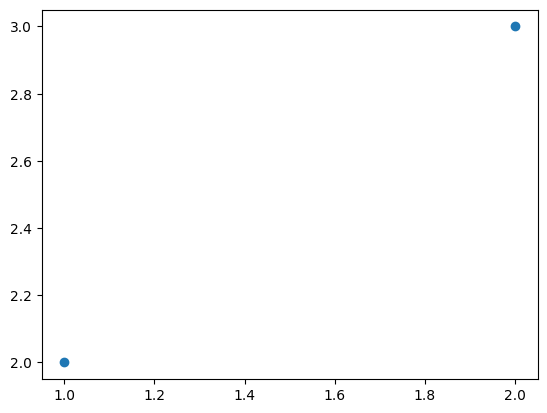

<Figure size 640x480 with 0 Axes>

In [148]:
plt.scatter(X,Y)
plt.show()
plt.clf()

Loss finale : 0.002418


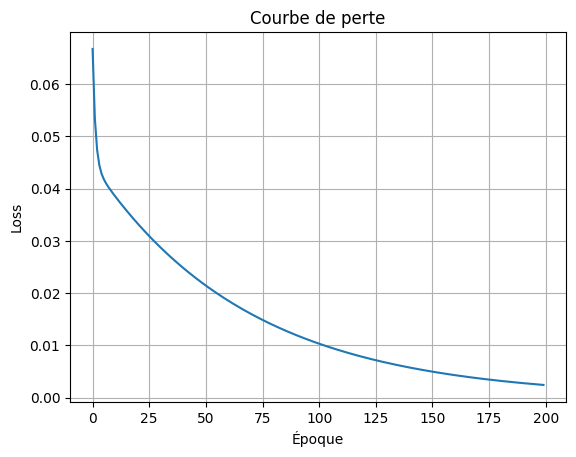

In [149]:
model = PMC([1, 1], learning_rate=0.1, is_regression=True)

losses = []
for epoch in range(200):
    loss = model.train(X, Y)
    losses.append(loss)

print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses)
plt.title("Courbe de perte")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.grid(True)
plt.show()

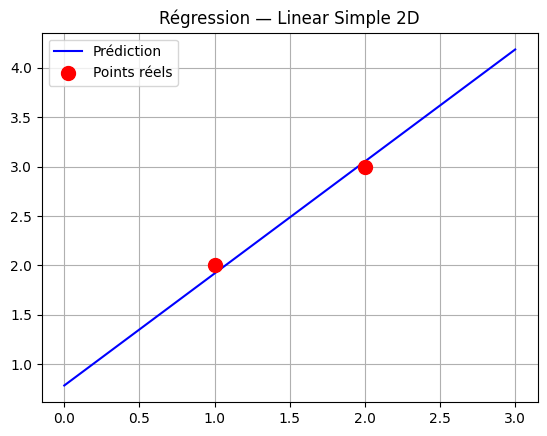

In [150]:
x_range = np.linspace(0, 3, 300).reshape(-1, 1)
y_pred = np.array([model.forward(pt)[0] for pt in x_range])

plt.plot(x_range, y_pred, color='blue', label='Prédiction')
plt.scatter(X, Y, color='red', s=100, zorder=5, label='Points réels')
plt.title("Régression — Linear Simple 2D")
plt.legend(); 
plt.grid(True)
plt.show()

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

In [151]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

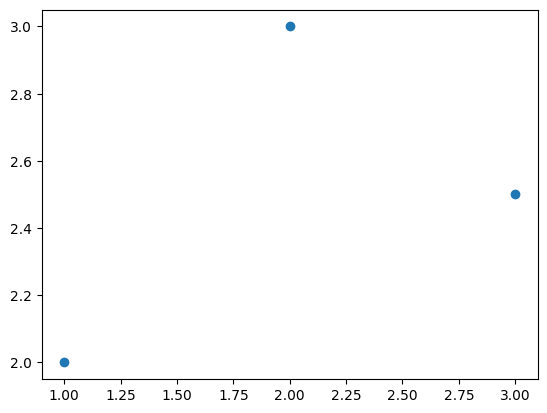

<Figure size 640x480 with 0 Axes>

In [152]:
plt.scatter(X,Y)
plt.show()
plt.clf()

In [153]:
model = PMC([1, 4, 1], learning_rate=0.1, is_regression=True)

losses = []
for epoch in range(10000):
    loss = model.train(X, Y)
    losses.append(loss)

print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses)
plt.title("Courbe de perte")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.grid(True)é
plt.show()

SyntaxError: invalid syntax (4039396415.py, line 13)

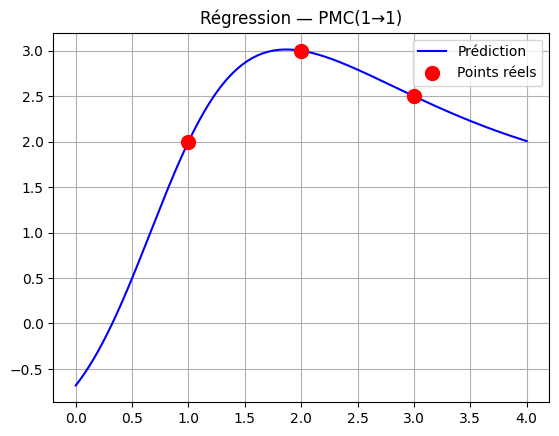

In [ ]:
x_range = np.linspace(0, 4, 300).reshape(-1, 1)
y_pred = np.array([model.forward(pt)[0] for pt in x_range])

plt.plot(x_range, y_pred, color='blue', label='Prédiction')
plt.scatter(X, Y, color='red', s=100, zorder=5, label='Points réels')
plt.title("Régression — PMC(1→1)")
plt.legend();
plt.grid(True)
plt.show()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [ ]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

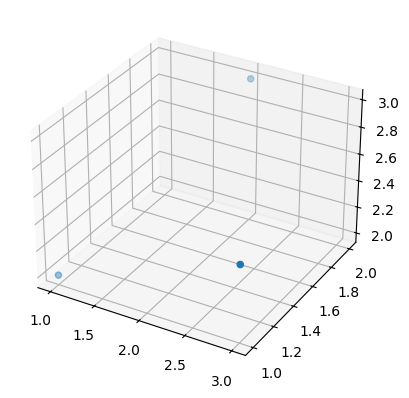

<Figure size 640x480 with 0 Axes>

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], Y)
plt.show()
plt.clf()

Loss finale : 0.001544


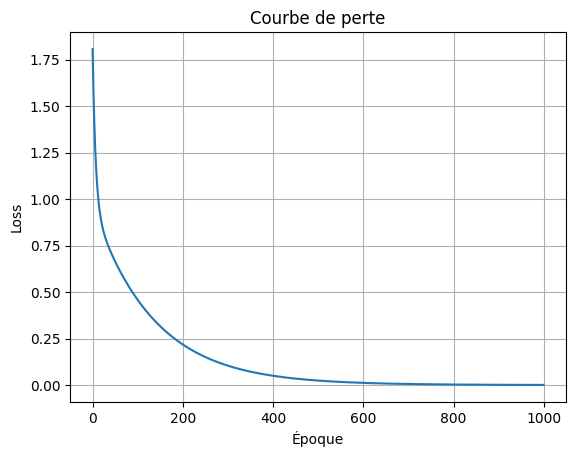

In [ ]:
model = PMC([2, 1], learning_rate=0.01, is_regression=True)

losses = []
for epoch in range(1000):
    loss = model.train(X, Y)
    losses.append(loss)

print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses)
plt.title("Courbe de perte")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.grid(True)
plt.show()

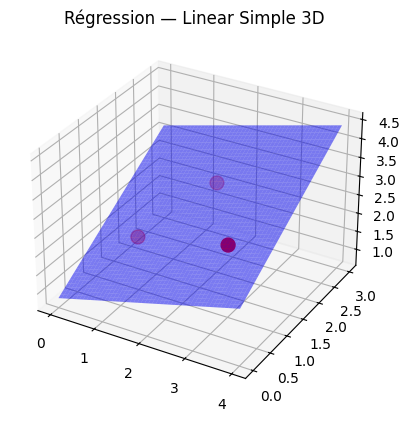

In [ ]:
x1_range = np.linspace(0, 4, 50)
x2_range = np.linspace(0, 3, 50)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid = np.c_[xx1.ravel(), xx2.ravel()]

y_pred = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx1.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx1, xx2, y_pred, alpha=0.5, color='blue')
ax.scatter(X[:,0], X[:,1], Y, color='red', s=100, zorder=5, label='Points réels')
ax.set_title("Régression — Linear Simple 3D")
plt.show()

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [ ]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

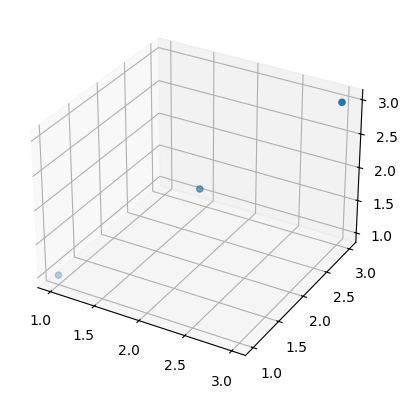

<Figure size 640x480 with 0 Axes>

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], Y)
plt.show()
plt.clf()

Loss finale : 0.000683


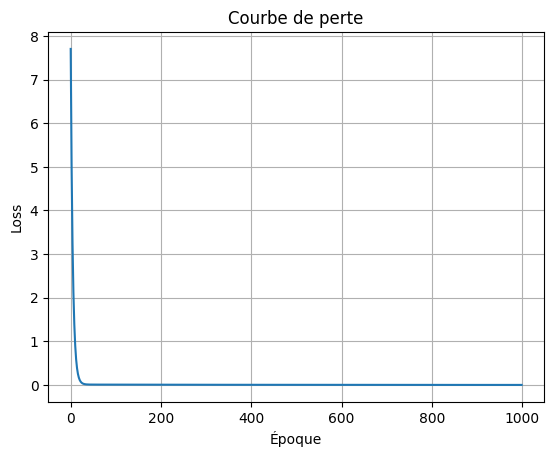

In [ ]:
model = PMC([2, 1], learning_rate=0.01, is_regression=True)

losses = []
for epoch in range(1000):
    loss = model.train(X, Y)
    losses.append(loss)

print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses)
plt.title("Courbe de perte")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.grid(True)
plt.show()

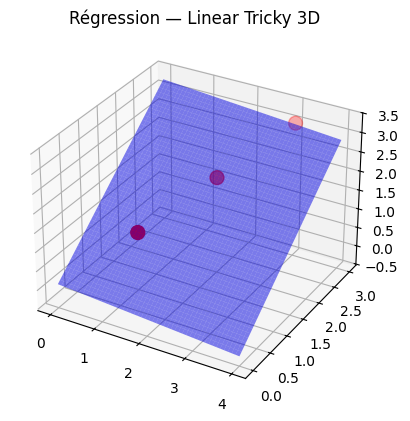

In [ ]:
x1_range = np.linspace(0, 4, 50)
x2_range = np.linspace(0, 3, 50)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid = np.c_[xx1.ravel(), xx2.ravel()]

y_pred = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx1.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx1, xx2, y_pred, alpha=0.5, color='blue')
ax.scatter(X[:,0], X[:,1], Y, color='red', s=100, zorder=5, label='Points réels')
ax.set_title("Régression — Linear Tricky 3D")
plt.show()

### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [ ]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

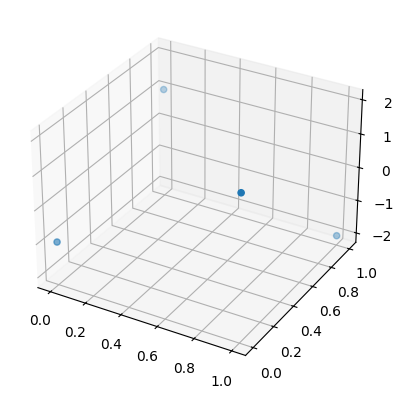

<Figure size 640x480 with 0 Axes>

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

Loss finale : 0.000643


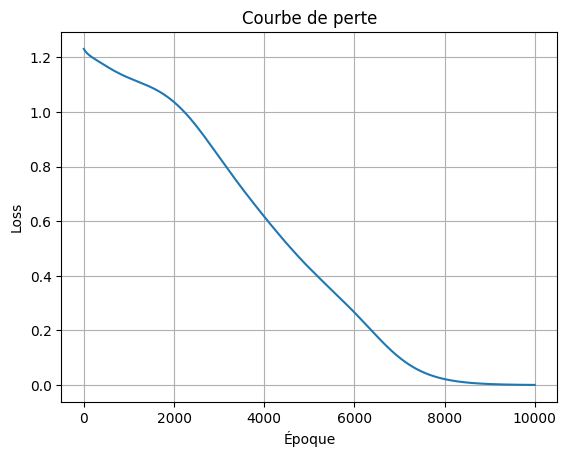

In [ ]:
model = PMC([2, 2, 1], learning_rate=0.001, is_regression=True)

losses = []
for epoch in range(10000):
    idx = np.random.permutation(len(X))
    epoch_loss = 0.0
    for i in idx:
        epoch_loss += model.train(X[i:i+1], Y[i:i+1])
    losses.append(epoch_loss / len(X))

print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses)
plt.title("Courbe de perte")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.grid(True)
plt.show()

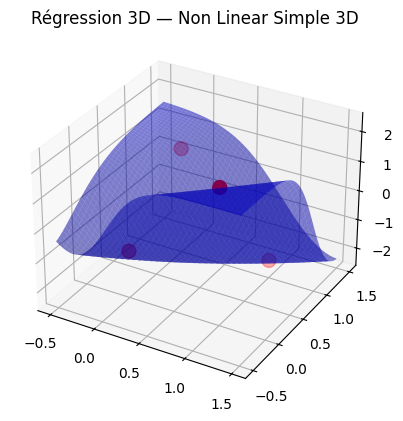

In [114]:
x1_range = np.linspace(-0.5, 1.5, 50)
x2_range = np.linspace(-0.5, 1.5, 50)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid = np.c_[xx1.ravel(), xx2.ravel()]

y_pred = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx1.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx1, xx2, y_pred, alpha=0.5, color='blue')
ax.scatter(X[:,0], X[:,1], Y, color='red', s=100, zorder=5, label='Points réels')
ax.set_title("Régression 3D — Non Linear Simple 3D")
plt.show()